For this notebook, we test the data sample using different setups for obtaining $\gamma_{\mathrm{PPN}}$ in the following scenarios:

- $\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_v$, $\mathtt{SEEING50}$
- $\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (deV, exp and petro radius), $\mathtt{SEEING50}$
- $\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING20}$, $\mathtt{SEEING50}$ and $\mathtt{SEEING80}$

In [1]:
# !pip install ipywidgets

In [2]:
import rings2cosmo
from getdist import plots, MCSamples
import getdist
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)

%matplotlib inline

In [3]:
mpl.rcParams.update(
    {
        "font.size": 20,
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
    }
)

# Data used for plotting and `rings2cosmo` script to obtain gamma_PPN:
colors = plt.cm.turbo(np.linspace(0.1, 0.9, 20))
labels = [r"\alpha", r"\beta", r"\delta", r"\gamma"]

In [4]:
# Loading the data
Data = pd.read_csv("01_LaStBeRu_cosmo_ground.csv")
len(Data)

132

Priors for each value:

- $\alpha$: Total mass density index
- $\beta$: Anisotropy parameter
- $\delta$: Luminosity density index
- $\gamma$: Parameterized Post-Newtonian parameter

In [5]:
alpha_true = 2
beta_true = 0.18
delta_true = 2.4
gamma_true = 1
nsteps = 15_000  # Number of steps

In [6]:
def get_mcmc(z_L, z_S, theta_E, theta_ap, seeing_atm, velDisp, velDispErr, label):
    sampler = rings2cosmo.logprobability_sampling(z_S, z_L, \
                                              velDisp, velDispErr, \
                                              theta_E, seeing_atm, theta_ap, \
                                              seed=42, alpha_ini=alpha_true, beta_ini=beta_true, delta_ini=delta_true, gamma_ini=gamma_true, \
                                              alpha_0_value=alpha_true, eps_alpha_0_value=0.08, beta_0_value=beta_true, eps_beta_0_value=0.13, delta_0_value=delta_true, eps_delta_0_value=0.11, \
                                              n_dim=4, n_walkers=64, n_burn=500, n_steps=nsteps, progress="notebook", processes=64)
    samples = MCSamples(samples=sampler.get_chain(discard=500, thin=1, flat=True), names=["alpha", "beta", "delta", "gamma"], labels=labels, \
                        label=label)
    # Customized triangle plot
    g = plots.get_subplot_plotter(subplot_size=4)
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.5
    g.settings.title_limit_fontsize = 20
    g.settings.axes_fontsize = 20
    g.settings.axes_labelsize = 20
    g.settings.legend_fontsize = 20
    g.triangle_plot(
        [samples],
        filled=True,
        legend_labels=[label],
        legend_loc="upper right",
        line_args=[{"ls": "--", "color": "black"}],
        contour_colors=["black"],
        title_limit=1,
        markers={
            "alpha": alpha_true, "beta": beta_true, "delta": delta_true, "gamma": gamma_true},
    )
    return samples

# 1. $\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_v$, $\mathtt{SEEING50}$

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_632437/1707233192.py:3: SyntaxWarning: invalid escape sequence '\m'
  label="$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_v$, $\mathtt{SEEING50}$")


Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


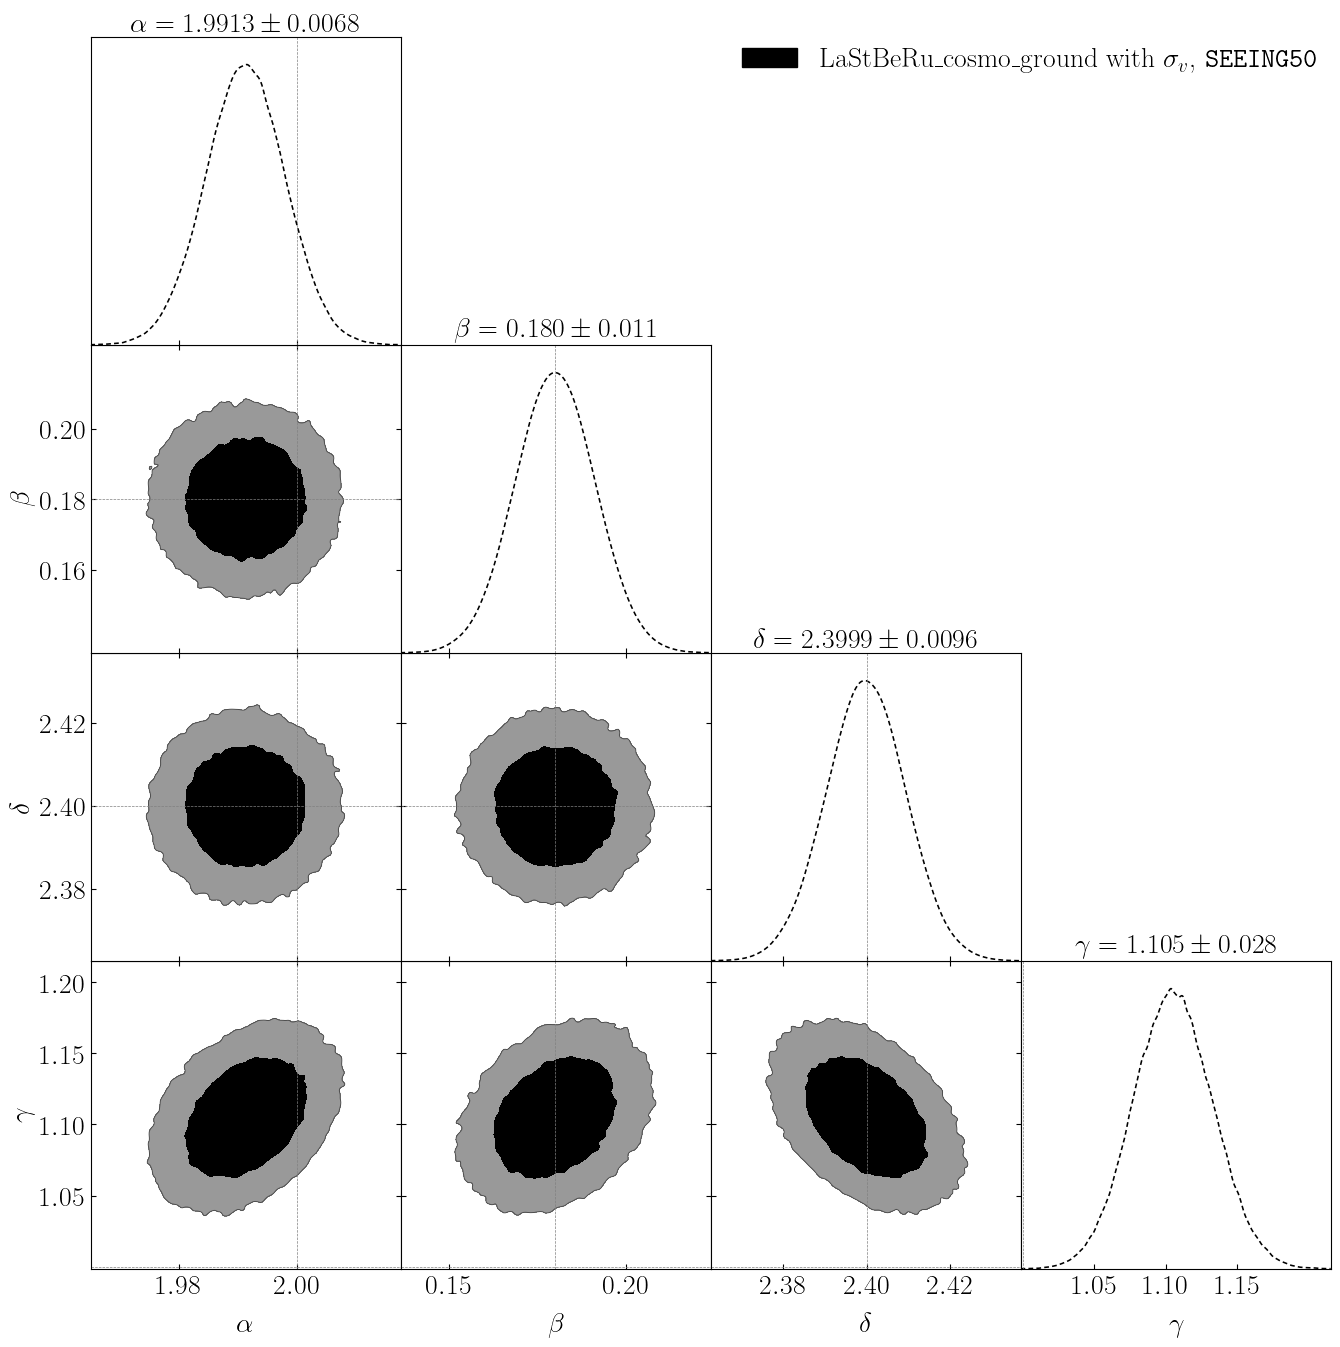

In [7]:
case_1 = get_mcmc(z_L=Data["z_L"].values, z_S=Data["z_S"].values, theta_E=Data["theta_E_rad"].values, theta_ap=Data["theta_ap_rad"].values, seeing_atm=Data["seeing50_rad"].values, \
                  velDisp=Data["velDisp"].values, velDispErr=Data["velDispErr"].values, \
                  label="$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_v$, $\mathtt{SEEING50}$")

# 2. $\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (deV, exp and petro radius), $\mathtt{SEEING50}$

## 2.1. $\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (deV radius), $\mathtt{SEEING50}$

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_632437/3079748008.py:3: SyntaxWarning: invalid escape sequence '\m'
  label="$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (deV radius), $\mathtt{SEEING50}$")


Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


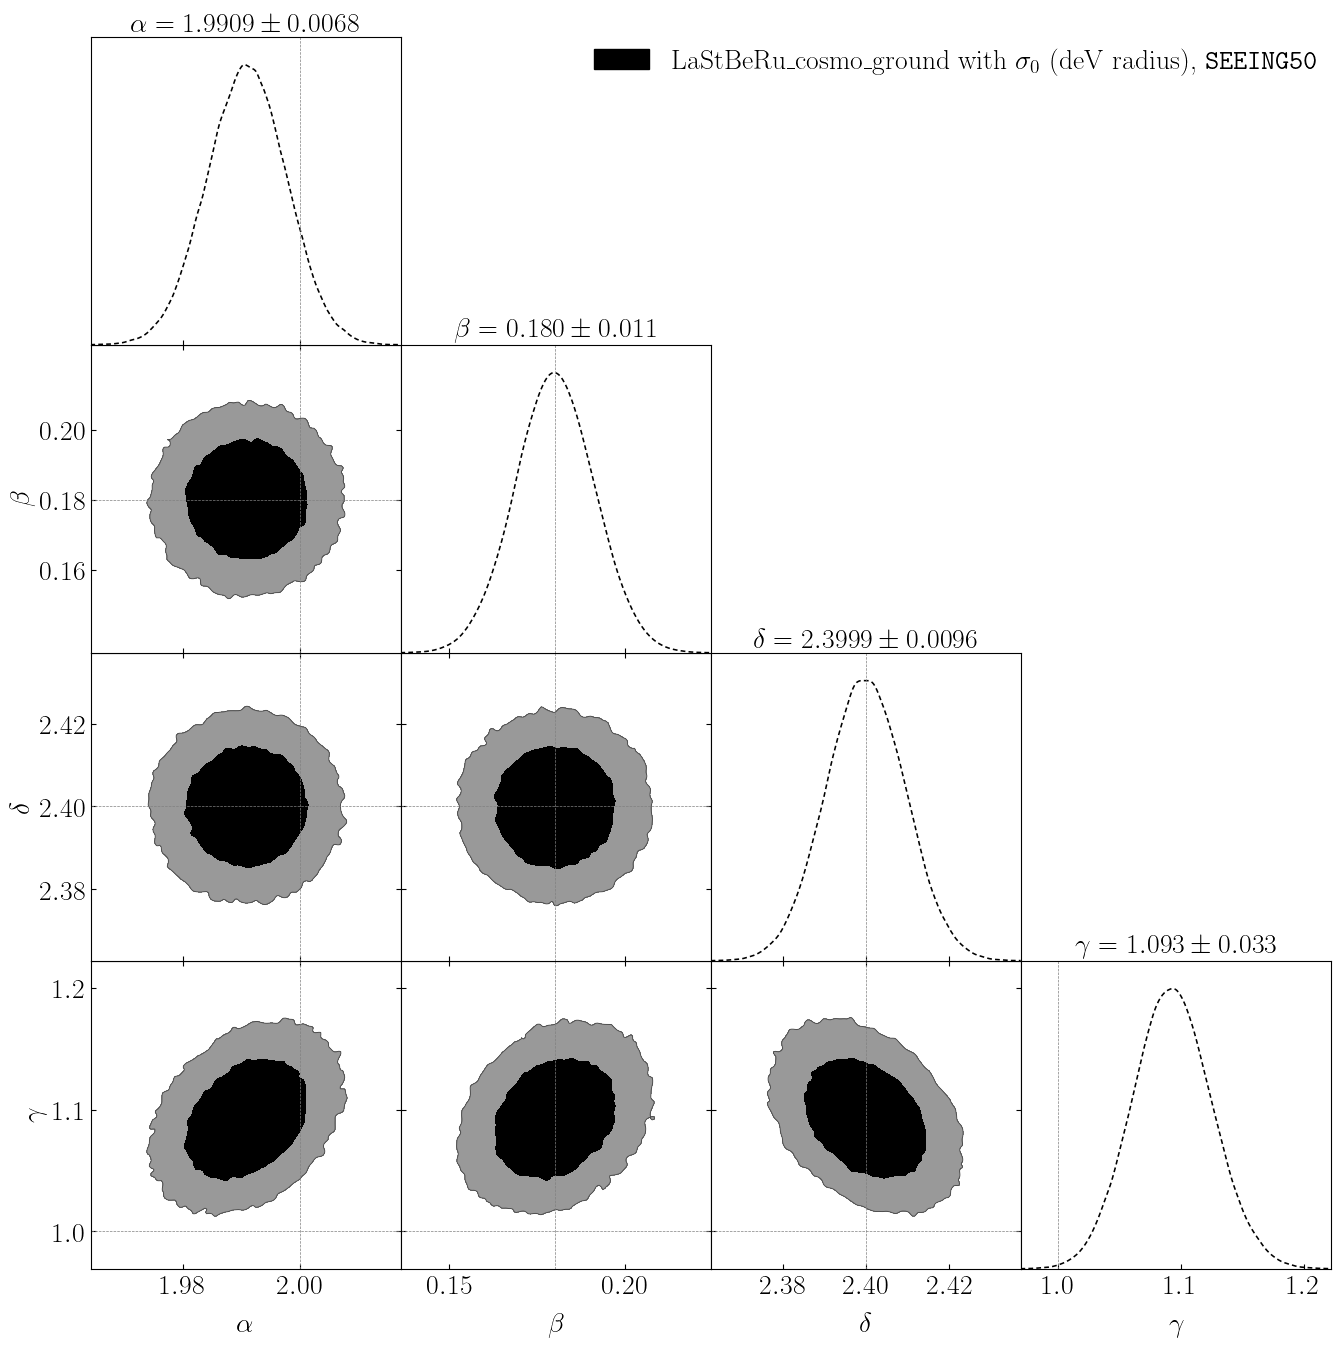

In [8]:
case_2_1 = get_mcmc(z_L=Data["z_L"].values, z_S=Data["z_S"].values, theta_E=Data["theta_E_rad"].values, theta_ap=Data["theta_ap_rad"].values, seeing_atm=Data["seeing50_rad"].values, \
                  velDisp=Data["velDisp0_dev"].values, velDispErr=Data["velDisp0Err_dev"].values, \
                  label="$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (deV radius), $\mathtt{SEEING50}$")

## 2.2 $\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (exp radius), $\mathtt{SEEING50}$

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_632437/2509140058.py:3: SyntaxWarning: invalid escape sequence '\m'
  label="$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (exp radius), $\mathtt{SEEING50}$")


Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


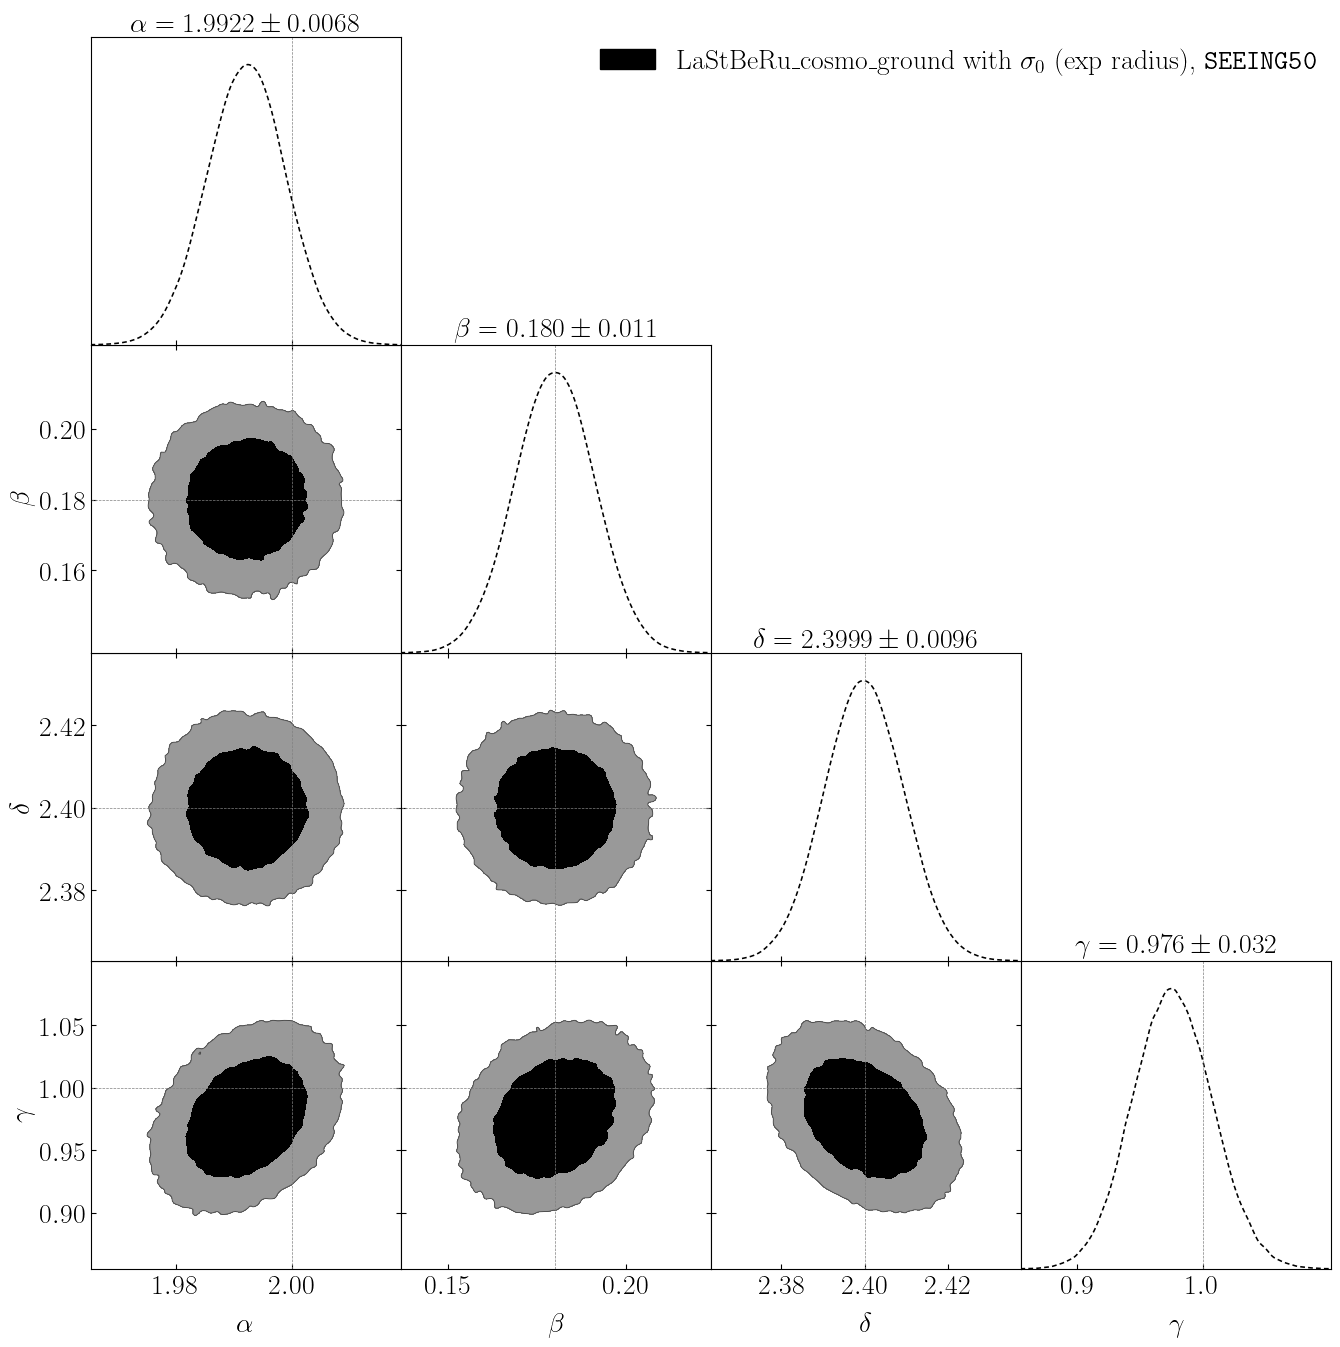

In [9]:
case_2_2 = get_mcmc(z_L=Data["z_L"].values, z_S=Data["z_S"].values, theta_E=Data["theta_E_rad"].values, theta_ap=Data["theta_ap_rad"].values, seeing_atm=Data["seeing50_rad"].values, \
                  velDisp=Data["velDisp0_exp"].values, velDispErr=Data["velDisp0Err_exp"].values, \
                  label="$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (exp radius), $\mathtt{SEEING50}$")

## 2.3. $\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (petro radius), $\mathtt{SEEING50}$

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_632437/3595824884.py:3: SyntaxWarning: invalid escape sequence '\m'
  label="$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (petro radius), $\mathtt{SEEING50}$")


Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


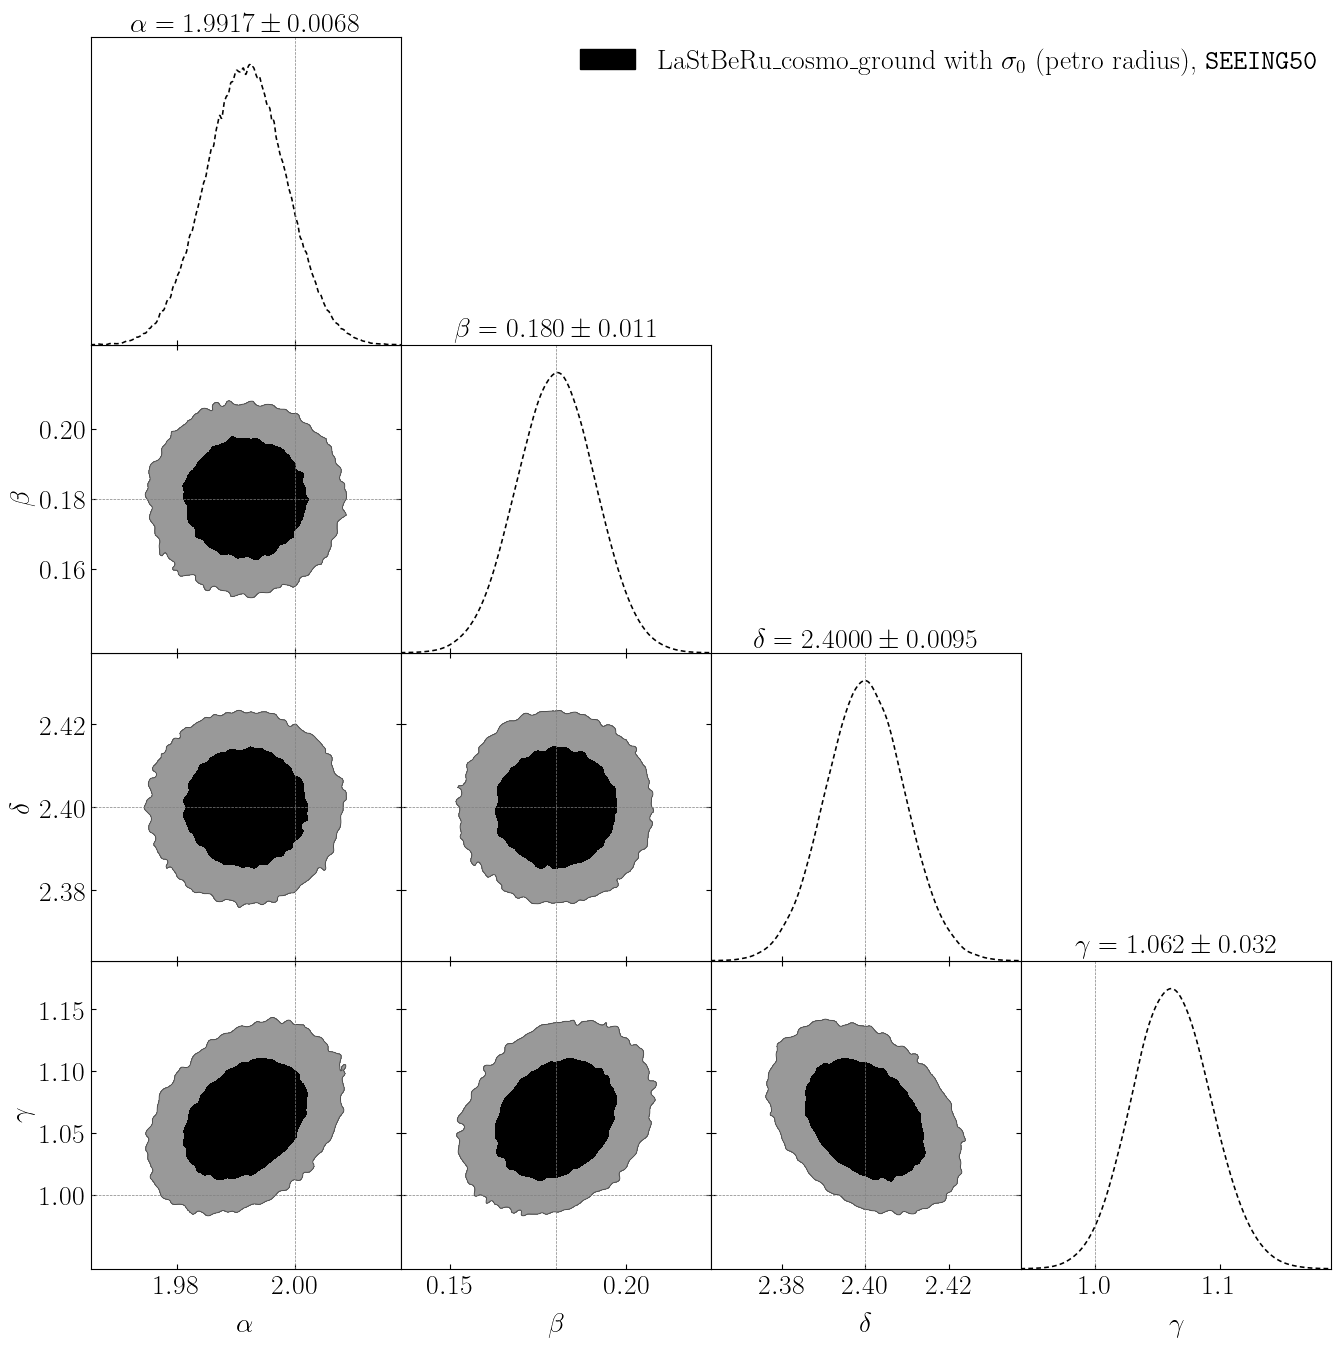

In [10]:
case_2_3 = get_mcmc(z_L=Data["z_L"].values, z_S=Data["z_S"].values, theta_E=Data["theta_E_rad"].values, theta_ap=Data["theta_ap_rad"].values, seeing_atm=Data["seeing50_rad"].values, \
                  velDisp=Data["velDisp0_petro"].values, velDispErr=Data["velDisp0Err_petro"].values, \
                  label="$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (petro radius), $\mathtt{SEEING50}$")

# 3. $\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING20}$, $\mathtt{SEEING50}$ and $\mathtt{SEEING80}$

## 3.1. $\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING20}$

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_632437/3448107615.py:3: SyntaxWarning: invalid escape sequence '\m'
  label="$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING20}$")


Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


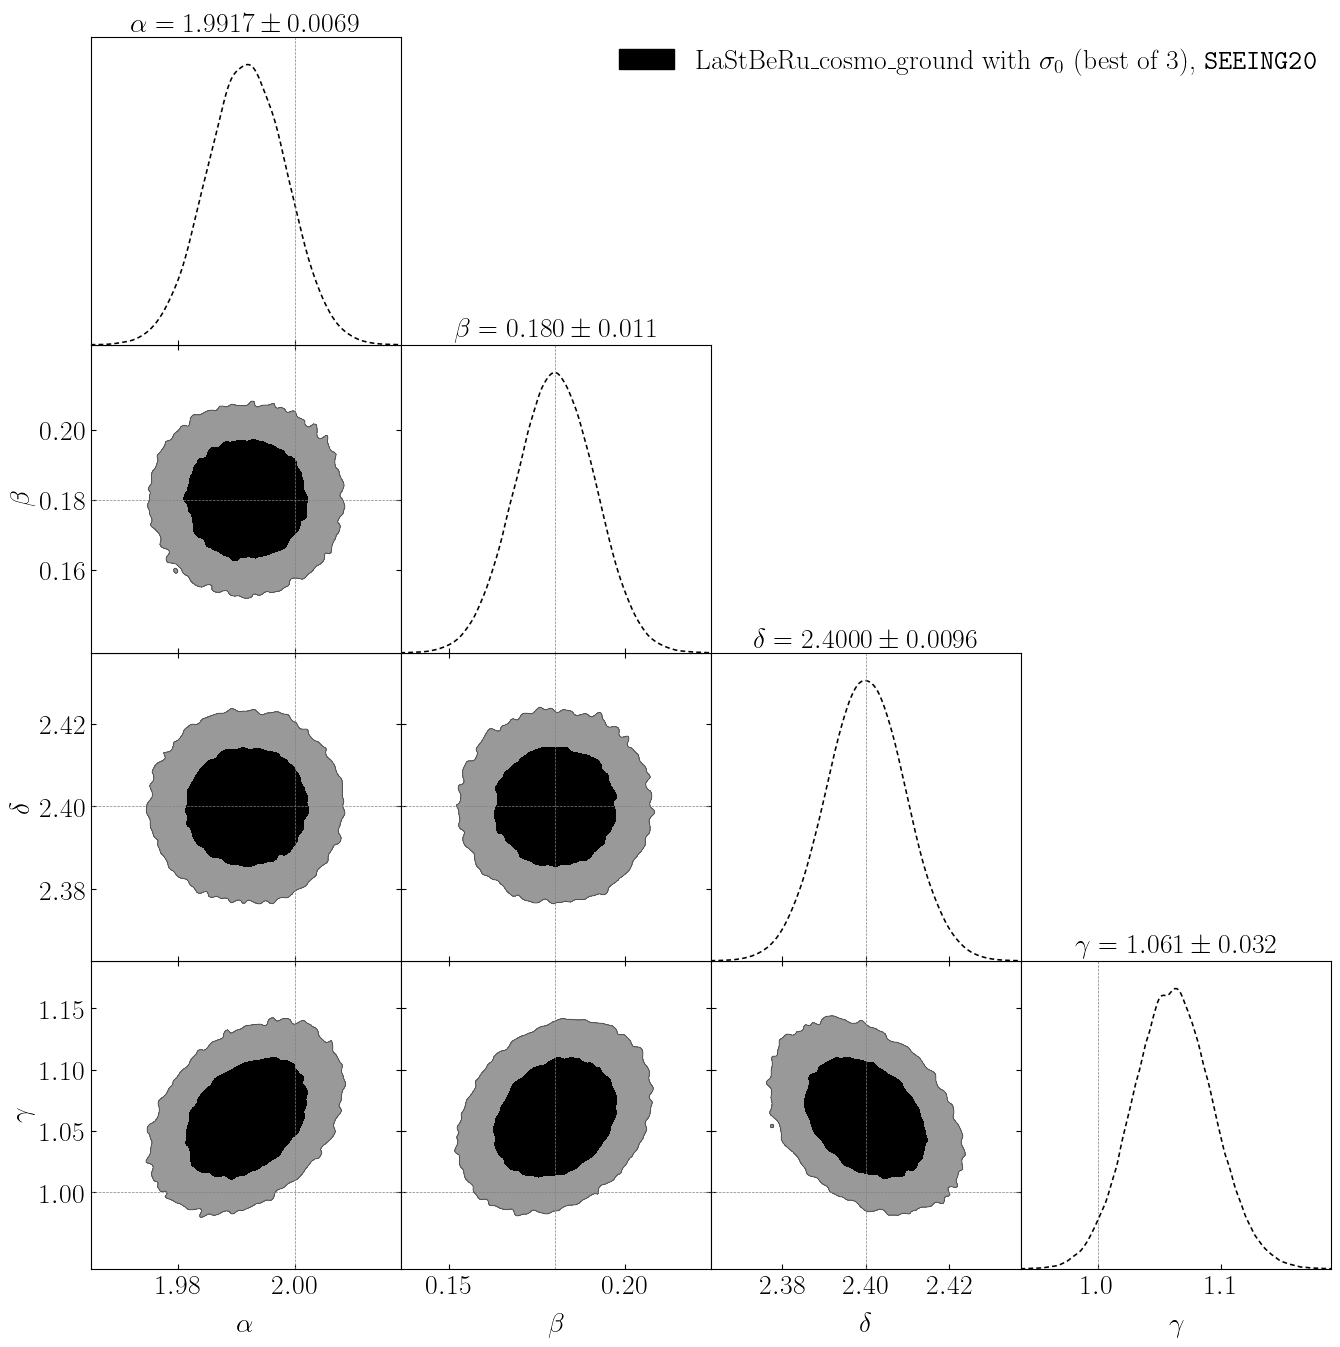

In [11]:
case_3_1 = get_mcmc(z_L=Data["z_L"].values, z_S=Data["z_S"].values, theta_E=Data["theta_E_rad"].values, theta_ap=Data["theta_ap_rad"].values, seeing_atm=Data["seeing20_rad"].values, \
                  velDisp=Data["velDisp0_petro"].values, velDispErr=Data["velDisp0Err_petro"].values, \
                  label="$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING20}$")

## 3.2. $\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING50}$

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_632437/2085231887.py:3: SyntaxWarning: invalid escape sequence '\m'
  label="$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING50}$")


Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


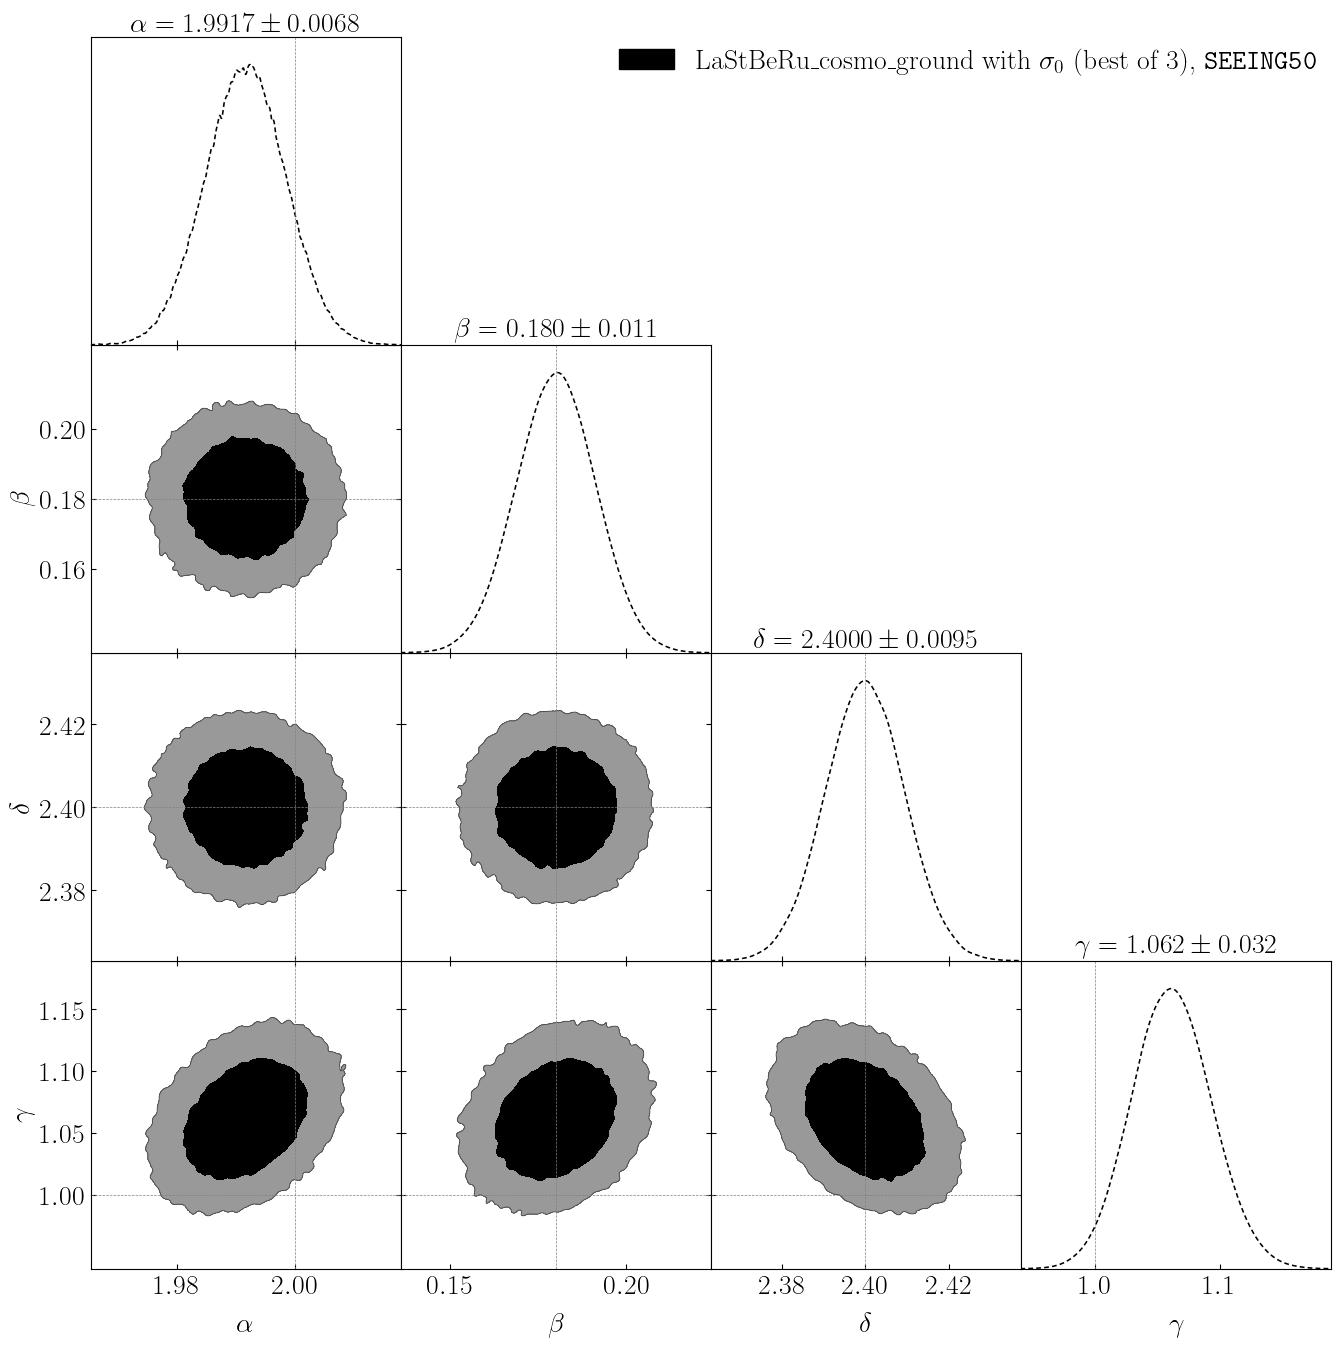

In [12]:
case_3_2 = get_mcmc(z_L=Data["z_L"].values, z_S=Data["z_S"].values, theta_E=Data["theta_E_rad"].values, theta_ap=Data["theta_ap_rad"].values, seeing_atm=Data["seeing50_rad"].values, \
                  velDisp=Data["velDisp0_petro"].values, velDispErr=Data["velDisp0Err_petro"].values, \
                  label="$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING50}$")

## 3.3. $\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING80}$

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_632437/4256401463.py:3: SyntaxWarning: invalid escape sequence '\m'
  label="$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING80}$")


Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


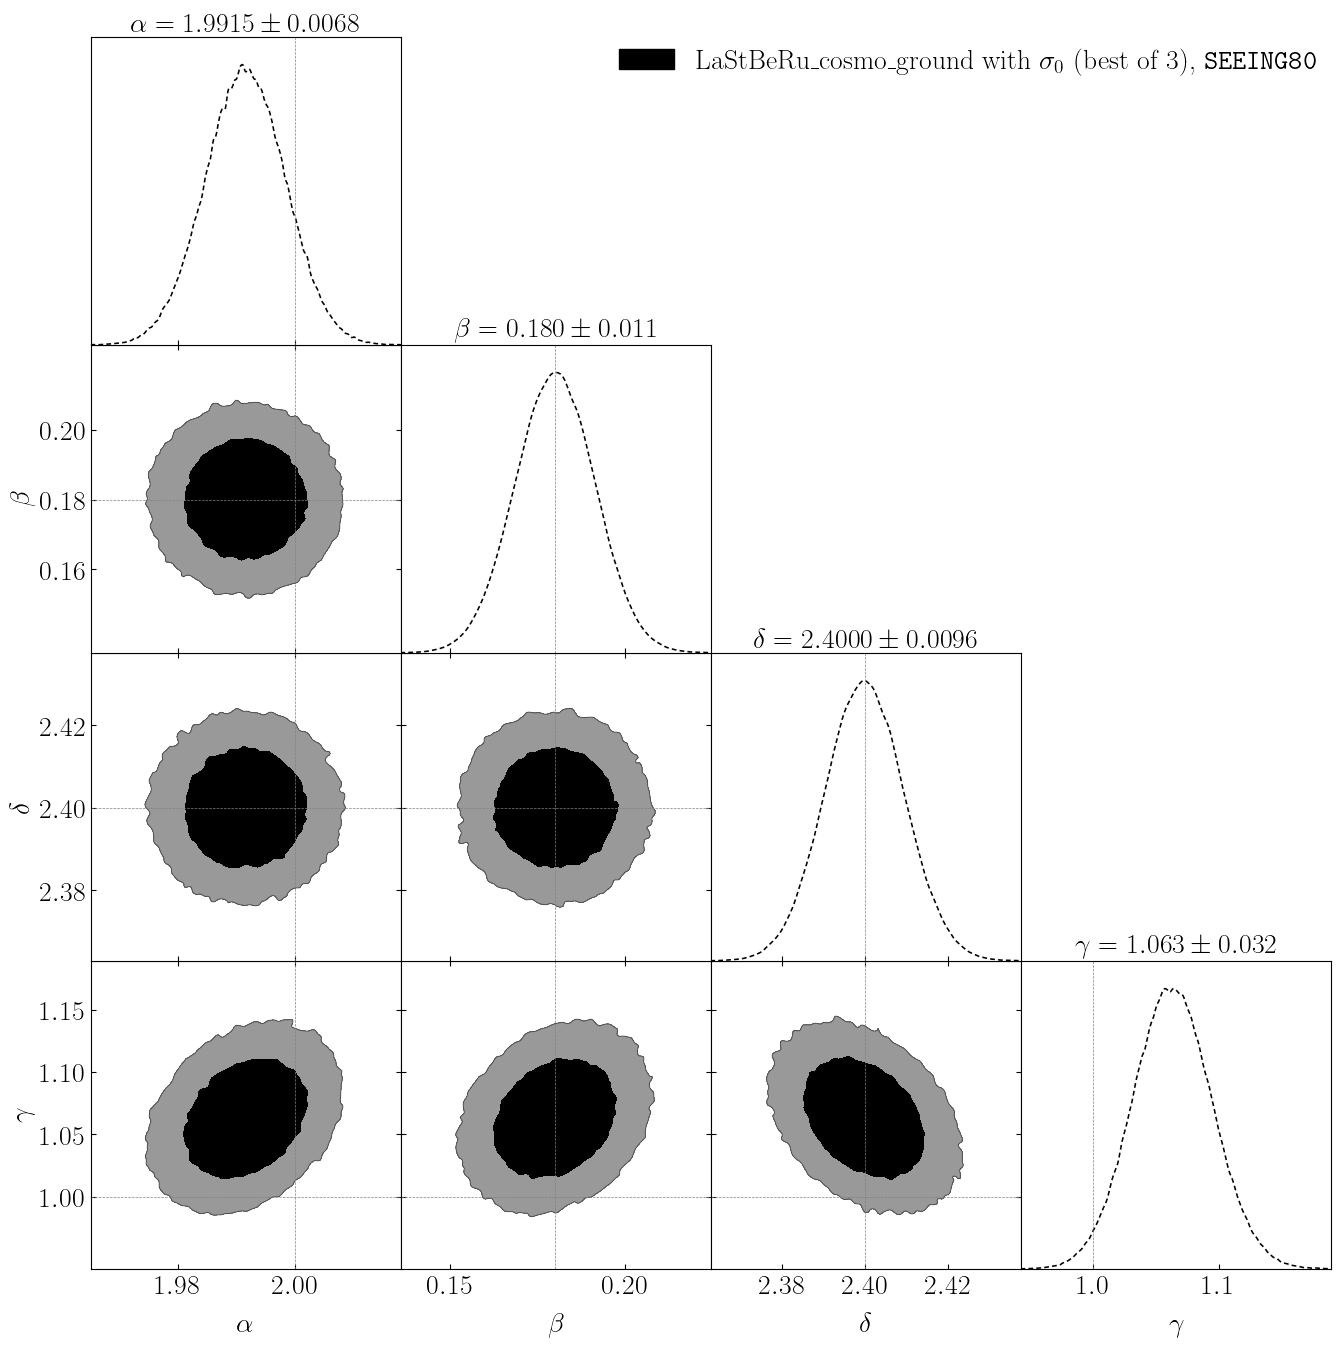

In [13]:
case_3_3 = get_mcmc(z_L=Data["z_L"].values, z_S=Data["z_S"].values, theta_E=Data["theta_E_rad"].values, theta_ap=Data["theta_ap_rad"].values, seeing_atm=Data["seeing80_rad"].values, \
                  velDisp=Data["velDisp0_petro"].values, velDispErr=Data["velDisp0Err_petro"].values, \
                  label="$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING80}$")

# Results

In [14]:
full_stats = [np.hstack([case_1.getMeans(), np.sqrt(case_1.getVars())]).T,
              np.hstack([case_2_1.getMeans(), np.sqrt(case_2_1.getVars())]).T,
              np.hstack([case_2_2.getMeans(), np.sqrt(case_2_2.getVars())]).T,
              np.hstack([case_2_3.getMeans(), np.sqrt(case_2_3.getVars())]).T,
              np.hstack([case_3_1.getMeans(), np.sqrt(case_3_1.getVars())]).T,
              np.hstack([case_3_2.getMeans(), np.sqrt(case_3_2.getVars())]).T,
              np.hstack([case_3_3.getMeans(), np.sqrt(case_3_3.getVars())]).T]
full_stats = np.vstack(full_stats)
columns = [r'$\alpha$', r'$\beta$', r'$\delta$', r'$\gamma$', r'$\mathrm{Std}(\alpha$)', r'$\mathrm{Std}(\beta$)', r'$\mathrm{Std}(\delta)$', r'$\mathrm{Std}(\gamma)$']
labels = [r'$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_v$, $\mathtt{SEEING50}$', \
          r'$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (deV radius), $\mathtt{SEEING50}$', \
          r'$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (exp radius), $\mathtt{SEEING50}$', \
          r'$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (petro radius), $\mathtt{SEEING50}$', \
          r'$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING20}$', \
          r'$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING50}$', \
          r'$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING80}$']

df = pd.DataFrame(full_stats, columns=columns)
# df.insert(0, 'Case', labels)
df.index = labels
df.insert(8, 'Number of Systems', [len(Data), len(Data), len(Data), len(Data), len(Data), len(Data), len(Data)])
df

,$\alpha$,$\beta$,$\delta$,$\gamma$,$\mathrm{Std}(\alpha$),$\mathrm{Std}(\beta$),$\mathrm{Std}(\delta)$,$\mathrm{Std}(\gamma)$,Number of Systems
"$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_v$, $\mathtt{SEEING50}$",1.991305,0.180057,2.399884,1.105152,0.006765,0.011339,0.009573,0.027892,132
"$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (deV radius), $\mathtt{SEEING50}$",1.990946,0.180073,2.399909,1.093013,0.006810,0.011368,0.009605,0.032549,132
"$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (exp radius), $\mathtt{SEEING50}$",1.992166,0.180021,2.399919,0.976147,0.006796,0.011263,0.009588,0.031739,132
"$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (petro radius), $\mathtt{SEEING50}$",1.991662,0.180079,2.399979,1.061583,0.006835,0.011308,0.009527,0.032065,132
"$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING20}$",1.991673,0.180175,2.399961,1.060800,0.006855,0.011319,0.009560,0.032339,132
"$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING50}$",1.991662,0.180079,2.399979,1.061583,0.006835,0.011308,0.009527,0.032065,132
"$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING80}$",1.991509,0.180126,2.399973,1.063289,0.006820,0.011366,0.009584,0.031662,132


In [13]:
full_stats = [np.hstack([case_1.getMeans(), np.sqrt(case_1.getVars())]).T,
              np.hstack([case_2_1.getMeans(), np.sqrt(case_2_1.getVars())]).T,
              np.hstack([case_2_2.getMeans(), np.sqrt(case_2_2.getVars())]).T,
              np.hstack([case_2_3.getMeans(), np.sqrt(case_2_3.getVars())]).T,
              np.hstack([case_3_1.getMeans(), np.sqrt(case_3_1.getVars())]).T,
              np.hstack([case_3_2.getMeans(), np.sqrt(case_3_2.getVars())]).T,
              np.hstack([case_3_3.getMeans(), np.sqrt(case_3_3.getVars())]).T]
full_stats = np.vstack(full_stats)
columns = [r'$\alpha$', r'$\beta$', r'$\delta$', r'$\gamma$', r'$\mathrm{Std}(\alpha$)', r'$\mathrm{Std}(\beta$)', r'$\mathrm{Std}(\delta)$', r'$\mathrm{Std}(\gamma)$']
labels = [r'$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_v$, $\mathtt{SEEING50}$', \
          r'$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (deV radius), $\mathtt{SEEING50}$', \
          r'$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (exp radius), $\mathtt{SEEING50}$', \
          r'$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (petro radius), $\mathtt{SEEING50}$', \
          r'$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING20}$', \
          r'$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING50}$', \
          r'$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING80}$']

df = pd.DataFrame(full_stats, columns=columns)
# df.insert(0, 'Case', labels)
df.index = labels
df.insert(8, 'Number of Systems', [len(Data), len(Data), len(Data), len(Data), len(Data), len(Data), len(Data)])
df

,$\alpha$,$\beta$,$\delta$,$\gamma$,$\mathrm{Std}(\alpha$),$\mathrm{Std}(\beta$),$\mathrm{Std}(\delta)$,$\mathrm{Std}(\gamma)$,Number of Systems
"$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_v$, $\mathtt{SEEING50}$",1.994189,0.180082,2.400065,1.083377,0.005469,0.009042,0.007676,0.024845,206
"$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (deV radius), $\mathtt{SEEING50}$",1.993835,0.180080,2.399959,1.052487,0.005470,0.009084,0.007665,0.028787,206
"$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (exp radius), $\mathtt{SEEING50}$",1.994546,0.180094,2.399992,0.935858,0.005477,0.009082,0.007642,0.028010,206
"$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (petro radius), $\mathtt{SEEING50}$",1.994260,0.180046,2.399895,1.023250,0.005512,0.009100,0.007641,0.028150,206
"$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING20}$",1.994274,0.179986,2.400045,1.021983,0.005516,0.009035,0.007667,0.028353,206
"$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING50}$",1.994260,0.180046,2.399895,1.023250,0.005512,0.009100,0.007641,0.028150,206
"$\mathrm{LaStBeRu\_cosmo\_ground}$ with $\sigma_0$ (best of 3), $\mathtt{SEEING80}$",1.994149,0.180014,2.399860,1.024151,0.005510,0.009037,0.007656,0.028152,206
